# Data.gov

## Scraping

In [ ]:
import json, time, random, gzip, requests

import re
import pandas as pd
from difflib import SequenceMatcher

from pathlib import Path

In [ ]:
BASE_URLS = [
    "https://catalog-beta.data.gov",
    "https://catalog.data.gov",
]

MAILTO = "maja.murawka@student.uva.nl"

def _safe_json(resp):
    ct = (resp.headers.get("content-type") or "").lower()
    if "json" not in ct:
        return None
    try:
        return resp.json()
    except Exception:
        return None

def get_page(base_url, params, session, timeout=60, max_tries=10):
    url = base_url.rstrip("/") + "/search"
    last = None
    for attempt in range(1, max_tries + 1):
        try:
            r = session.get(
                url,
                params=params,
                headers={
                    "Accept": "application/json",
                    "User-Agent": f"catalog-harvest/1.0 (mailto:{MAILTO})",
                },
                timeout=timeout,
                allow_redirects=True,
            )

            if r.status_code == 202:
                time.sleep(min(2**attempt, 30) + random.random())
                continue

            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep(min(2**attempt, 30) + random.random())
                continue

            if r.status_code != 200:
                last = RuntimeError(f"status={r.status_code} ct={r.headers.get('content-type')} head={r.text[:120]!r}")
                time.sleep(min(2**attempt, 30) + random.random())
                continue

            data = _safe_json(r)
            if data is None:
                last = RuntimeError(f"non-json ct={r.headers.get('content-type')} head={r.text[:120]!r}")
                time.sleep(min(2**attempt, 30) + random.random())
                continue

            return data

        except Exception as e:
            last = e
            time.sleep(min(2**attempt, 30) + random.random())

    raise RuntimeError(f"failed after retries: {last}")

def catalog_search(params, session=None, base_urls=None):
    if session is None:
        session = requests.Session()
    if base_urls is None:
        base_urls = BASE_URLS

    last_err = None
    for base in base_urls:
        try:
            return get_page(base, params, session=session)
        except Exception as e:
            last_err = e
            continue
    raise RuntimeError(f"all base urls failed. last_err={last_err}")

def probe_max_per_page(q=""):
    s = requests.Session()
    for pp in [5000, 2000, 1000, 500, 200, 100]:
        try:
            j = catalog_search({"q": q, "per_page": pp}, session=s, base_urls=["https://catalog-beta.data.gov"])
            n = len(j.get("results") or [])
            if n > 0:
                print("probe per_page", pp, "-> got", n)
                return pp
        except Exception as e:
            print("probe per_page", pp, "failed:", str(e)[:120])
    return 200

def export_catalog_jsonl(
    out_path="datagov_catalog.jsonl",
    checkpoint_path="datagov_catalog.checkpoint.json",
    q="",
    per_page=None,
    limit=None,
    print_every_pages=20,
    polite_sleep=0.0,
):
    out_path = Path(out_path)
    checkpoint_path = Path(checkpoint_path)

    session = requests.Session()

    after = None
    written = 0
    pages = 0
    t0 = time.time()

    if checkpoint_path.exists() and out_path.exists():
        state = json.loads(checkpoint_path.read_text(encoding="utf-8"))
        after = state.get("after")
        written = int(state.get("written", 0))
        pages = int(state.get("pages", 0))
        print("resuming from checkpoint:", {"written": written, "pages": pages, "after": (str(after)[:40] + "...") if after else None})

    if per_page is None:
        per_page = probe_max_per_page(q=q)
        print("using per_page =", per_page)

    mode = "a" if out_path.exists() and written > 0 else "w"
    with out_path.open(mode, encoding="utf-8") as f:
        while True:
            params = {"q": q, "per_page": int(per_page)}
            if after:
                params["after"] = after

            page = catalog_search(params, session=session, base_urls=["https://catalog-beta.data.gov"])
            results = page.get("results") or []
            after = page.get("after")

            if not results:
                print("no results; stopping")
                break

            for rec in results:
                f.write(json.dumps(rec, ensure_ascii=False) + "\n")
                written += 1
                if limit is not None and written >= limit:
                    checkpoint_path.write_text(json.dumps({"after": after, "written": written, "pages": pages}), encoding="utf-8")
                    print("hit limit; stopping at", written)
                    return

            pages += 1
            checkpoint_path.write_text(json.dumps({"after": after, "written": written, "pages": pages}), encoding="utf-8")

            if pages % print_every_pages == 0:
                dt = time.time() - t0
                rate = written / dt if dt > 0 else 0
                print(f"pages={pages} written={written} rate={rate:.1f}/s after={(str(after)[:40] + '...') if after else None}")

            if not after:
                print("no after cursor; done")
                break

            if polite_sleep:
                time.sleep(polite_sleep)

    print("done:", {"written": written, "pages": pages, "file": str(out_path)})

# --- Recommended workflow ---
# 1) quick test (fast):
# export_catalog_jsonl(out_path="datagov_test.jsonl", checkpoint_path="datagov_test.checkpoint.json", per_page=200, limit=2000)
#
# 2) full export:
# export_catalog_jsonl(out_path="datagov_full.jsonl", checkpoint_path="datagov_full.checkpoint.json", q="", per_page=None, limit=None, print_every_pages=10)

In [ ]:
# export_catalog_jsonl(out_path="datagov_test.jsonl", checkpoint_path="datagov_test.checkpoint.json", per_page=200, limit=2000)
export_catalog_jsonl(out_path="datagov_full.jsonl", checkpoint_path="datagov_full.checkpoint.json", q="", per_page=None, limit=None, print_every_pages=10)

probe per_page 5000 -> got 5000
using per_page = 5000
pages=10 written=50000 rate=1027.5/s after=WzEuMCwxLCJhZTZmNmRmOC01OGE2LTQxMGYtYTA5...
pages=20 written=100000 rate=1048.7/s after=WzEuMCwwLCJmYjU1NGI4Zi0yOWYyLTQyYWItOTAy...
pages=30 written=150000 rate=1032.9/s after=WzEuMCwwLCJkY2YxNzE3YS0zZDdmLTRmMzYtOWFi...
pages=40 written=200000 rate=1035.3/s after=WzEuMCwwLCJiZWU1ZjI4Yy1kNDg0LTQ2YWUtOWJk...
pages=50 written=250000 rate=1034.4/s after=WzEuMCwwLCJhMDdhMTI2Mi01NjcxLTQwNTAtOWIw...
pages=60 written=300000 rate=1041.2/s after=WzEuMCwwLCI4MjI1ODAyOC04YTY4LTRkZjEtYThi...
pages=70 written=350000 rate=1036.0/s after=WzEuMCwwLCI2M2NiMDU3Yy01MTI3LTRiMjEtYTM3...
pages=80 written=400000 rate=1035.6/s after=WzEuMCwwLCI0NTRhOWFiNC1iN2IxLTRhOTAtOTE2...
pages=90 written=450000 rate=1035.3/s after=WzEuMCwwLCIyNzA2YTFjMi0yMGUxLTQxNDItODRi...
pages=100 written=500000 rate=1038.6/s after=WzEuMCwwLCIwOGJhOGMxMS03ZGEyLTRkNjgtYTA3...
no after cursor; done
done: {'written': 514352, 'pages': 103, 'fil

## Matching with DRP

In [40]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from general.util.banned_words import add_flagged_column

In [2]:
import re
import pandas as pd
from difflib import SequenceMatcher

def norm_title(x):
    x = str(x).lower().strip()
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

In [38]:
df_drp = pd.read_csv('00_data/drp_withdoi.csv')

In [4]:
df_dg = pd.read_json('datagov_full.jsonl', lines=True)

In [5]:
df_drp.columns

Index(['Unnamed: 0', 'file', 'schema', 'title', 'organization', 'agency',
       'websites', 'data_source', 'last_modified', 'metadata_available',
       'category', 'resource_count', 'project_title', 'id', 'url', 'format',
       'status', 'size', 'download_date', 'maintainer', 'notes', 'domain',
       'doi', 'project_id', 'version', 'doi_guess', 'doi_norm', 'dc_ok',
       'dc_status', 'dc_prefix', 'dc_suffix', 'dc_publisher',
       'dc_publicationYear', 'dc_language', 'dc_version', 'dc_url',
       'dc_schemaVersion', 'dc_source', 'dc_isActive', 'dc_state',
       'dc_metadataVersion', 'dc_created', 'dc_registered', 'dc_published',
       'dc_updated', 'dc_viewCount', 'dc_downloadCount', 'dc_referenceCount',
       'dc_citationCount', 'dc_partCount', 'dc_partOfCount', 'dc_versionCount',
       'dc_versionOfCount', 'dc_types_ris', 'dc_types_bibtex',
       'dc_types_citeproc', 'dc_types_schemaOrg',
       'dc_types_resourceTypeGeneral', 'dc_identifiers',
       'dc_alternateIdentif

In [6]:
df_dg.columns

Index(['_score', '_sort', 'dcat', 'description', 'harvest_record',
       'harvest_record_raw', 'has_spatial', 'identifier', 'keyword',
       'last_harvested_date', 'organization', 'popularity', 'publisher',
       'slug', 'spatial_shape', 'theme', 'title',
       'harvest_record_transformed'],
      dtype='object')

In [7]:
df_drp = df_drp.copy()
df_dg = df_dg.copy()

In [8]:
df_drp["title_norm"] = df_drp["project_title"].apply(norm_title)
df_dg["title_norm"] = df_dg["title"].apply(norm_title)

In [9]:
def title_similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()

In [ ]:
def norm_title(x):
    x = str(x).lower().strip()
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def first_token(x):
    x = norm_title(x)
    return x.split()[0] if x else ""

def title_similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()

df_drp["title_norm"] = df_drp["project_title"].apply(norm_title)
df_drp["first_token"] = df_drp["project_title"].apply(first_token)
df_dg["title_norm"] = df_dg["title"].apply(norm_title)
df_dg["first_token"] = df_dg["title"].apply(first_token)
df_dg["title_len"] = df_dg["title_norm"].str.len()

In [11]:
matches = []

for i, row in df_drp.iterrows():
    drp_title = row["project_title"]
    drp_norm = row["title_norm"]
    token = row["first_token"]
    drp_len = len(drp_norm)

    candidates = df_dg[
        (df_dg["first_token"] == token) &
        (df_dg["title_len"].between(drp_len - 20, drp_len + 20))
    ]

    if len(candidates) == 0:
        continue

    best_score = -1
    best_idx = None

    for j, dg_row in candidates.iterrows():
        score = title_similarity(drp_norm, dg_row["title_norm"])
        if score > best_score:
            best_score = score
            best_idx = j

    matches.append({
        "drp_index": i,
        "drp_title": drp_title,
        "dg_index": best_idx,
        "match_score": best_score
    })

match_df = pd.DataFrame(matches)

In [12]:
match_df = match_df.merge(
    df_dg.reset_index().add_prefix("dg_"),
    left_on="dg_index",
    right_on="dg_index",
    how="left"
)

match_df = match_df.merge(
    df_drp.reset_index().add_prefix("drp_"),
    left_on="drp_index",
    right_on="drp_index",
    how="left"
)

In [13]:
df_dg = df_dg[df_dg["title"].notna()].copy()
df_dg = df_dg[df_dg["title"].str.len() > 10].copy()

In [14]:
print(match_df["match_score"].describe())

print(
    match_df[["drp_title_x", "dg_title", "match_score"]]
    .sort_values("match_score", ascending=False)
    .head(20)
)

print(
    match_df[["drp_title_x", "dg_title", "match_score"]]
    .sort_values("match_score")
    .head(20)
)

count    1827.000000
mean        0.819047
std         0.233819
min         0.189474
25%         0.609847
50%         1.000000
75%         1.000000
max         1.000000
Name: match_score, dtype: float64
                                            drp_title_x  \
1826             YRBS State Tobacco Variables 2013 - v2   
1732  Visits to physician offices, hospital outpatie...   
762   Measles Case and Genetic Metadata, Operation A...   
763   Medicaid Claims (MAX) - Vision and Eye Health ...   
764   Medicaid coverage among persons under age 65, ...   
765   Medicaid Coverage Of Cessation Treatments And ...   
766                           Medicaid Spending by Drug   
768            Medicare COVID-19 Hospitalization Trends   
769   Medicare Current Beneficiary Survey - Survey File   
771                        Medicare Dialysis Facilities   
772   Medicare Durable Medical Equipment, Devices & ...   
773   Medicare Fee for Service (FFS) claims (100%) –...   
774   Medicare Fee-For-Service 

In [15]:
(match_df["match_score"] == 1).sum()

917

In [16]:
(match_df["match_score"] == 1).mean()

0.5019157088122606

In [45]:
sorted(match_df.columns)

['dg__score',
 'dg__sort',
 'dg_dcat',
 'dg_description',
 'dg_first_token',
 'dg_harvest_record',
 'dg_harvest_record_raw',
 'dg_harvest_record_transformed',
 'dg_has_spatial',
 'dg_identifier',
 'dg_index',
 'dg_keyword',
 'dg_last_harvested_date',
 'dg_organization',
 'dg_popularity',
 'dg_publisher',
 'dg_slug',
 'dg_spatial_shape',
 'dg_theme',
 'dg_title',
 'dg_title_len',
 'dg_title_norm',
 'drp_Unnamed: 0',
 'drp_agency',
 'drp_category',
 'drp_data_source',
 'drp_dc_abstract',
 'drp_dc_alternateIdentifiers',
 'drp_dc_citationCount',
 'drp_dc_contributors_all',
 'drp_dc_created',
 'drp_dc_creators_all',
 'drp_dc_creators_names',
 'drp_dc_creators_types',
 'drp_dc_date_collected',
 'drp_dc_date_issued',
 'drp_dc_dates_all',
 'drp_dc_descriptions_all',
 'drp_dc_downloadCount',
 'drp_dc_error',
 'drp_dc_fundingReferences',
 'drp_dc_geoLocations_all',
 'drp_dc_geo_places',
 'drp_dc_identifiers',
 'drp_dc_isActive',
 'drp_dc_isVersionOf',
 'drp_dc_language',
 'drp_dc_metadataVersion

In [47]:
cols_compare = [
    "drp_dc_title", "dg_title",
    "drp_dc_abstract", "dg_description",
    "drp_dc_created", "drp_dc_registered", "drp_dc_updated", "drp_dc_published",
    "dg_last_harvested_date",
    "drp_dc_subjects", "dg_theme", "dg_keyword",
    "drp_dc_publisher", "dg_publisher",
    "drp_dc_fundingReferences",
    "drp_dc_language",
    "drp_doi"
]

print(
    pd.DataFrame({
        "pct_missing": match_df[cols_compare].isna().mean().sort_values()
    })
)

                          pct_missing
drp_dc_title                 0.000000
drp_dc_fundingReferences     0.000000
dg_publisher                 0.000000
drp_dc_publisher             0.000000
dg_keyword                   0.000000
drp_dc_published             0.000000
dg_last_harvested_date       0.000000
drp_dc_registered            0.000000
drp_dc_created               0.000000
dg_description               0.000000
drp_dc_abstract              0.000000
dg_title                     0.000000
drp_dc_updated               0.000000
drp_doi                      0.000000
dg_theme                     0.004926
drp_dc_language              0.038314
drp_dc_subjects              0.271483


In [48]:
match_df["drp_title_len"] = match_df["drp_dc_title"].astype(str).str.split().str.len()
match_df["dg_title_len_words"] = match_df["dg_title"].astype(str).str.split().str.len()

match_df["drp_abstract_len"] = match_df["drp_dc_abstract"].astype(str).str.split().str.len()
match_df["dg_description_len"] = match_df["dg_description"].astype(str).str.split().str.len()

print(
    match_df[["drp_title_len", "dg_title_len_words", "drp_abstract_len", "dg_description_len"]]
    .describe()
)

       drp_title_len  dg_title_len_words  drp_abstract_len  dg_description_len
count    1827.000000         1827.000000       1827.000000         1827.000000
mean        9.447729            8.939245        195.481117          137.133005
std         5.109628            5.349364        352.040592          131.735398
min         1.000000            1.000000          1.000000            1.000000
25%         6.000000            5.000000         51.000000           40.000000
50%         8.000000            8.000000        111.000000           87.000000
75%        12.000000           11.000000        251.500000          209.500000
max        40.000000           40.000000       9262.000000          798.000000


In [50]:
match_df["title_len_diff"] = match_df["dg_title_len_words"] - match_df["drp_title_len"]
match_df["desc_len_diff"] = match_df["dg_description_len"] - match_df["drp_abstract_len"]

print(match_df[["title_len_diff", "desc_len_diff"]].describe())

       title_len_diff  desc_len_diff
count     1827.000000    1827.000000
mean        -0.508484     -58.348112
std          2.421678     344.048107
min        -15.000000   -9207.000000
25%         -1.000000     -40.500000
50%          0.000000      -2.000000
75%          0.000000       0.000000
max         14.000000     572.000000


In [51]:
date_cols = [
    "drp_dc_created", "drp_dc_registered", "drp_dc_updated", "drp_dc_published",
    "drp_dc_date_collected", "drp_dc_date_issued",
    "dg_last_harvested_date"
]

for c in date_cols:
    match_df[c + "_parsed"] = pd.to_datetime(match_df[c], errors="coerce")

print(
    pd.DataFrame({
        "pct_available": match_df[[c + "_parsed" for c in date_cols]].notna().mean().sort_values(ascending=False)
    })
)

                               pct_available
drp_dc_created_parsed               1.000000
drp_dc_registered_parsed            1.000000
drp_dc_updated_parsed               1.000000
drp_dc_published_parsed             1.000000
dg_last_harvested_date_parsed       1.000000
drp_dc_date_issued_parsed           0.979201
drp_dc_date_collected_parsed        0.037767


/var/folders/f0/g61h031s7yscf43_m6xj3l0c0000gn/T/ipykernel_4433/3771447528.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  match_df[c + "_parsed"] = pd.to_datetime(match_df[c], errors="coerce")
/var/folders/f0/g61h031s7yscf43_m6xj3l0c0000gn/T/ipykernel_4433/3771447528.py:8: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  match_df[c + "_parsed"] = pd.to_datetime(match_df[c], errors="coerce")


In [52]:
match_df["drp_created_year"] = match_df["drp_dc_created_parsed"].dt.year
match_df["drp_registered_year"] = match_df["drp_dc_registered_parsed"].dt.year
match_df["drp_updated_year"] = match_df["drp_dc_updated_parsed"].dt.year
match_df["drp_published_year"] = match_df["drp_dc_published_parsed"].dt.year
match_df["dg_harvested_year"] = match_df["dg_last_harvested_date_parsed"].dt.year

print(
    match_df[[
        "drp_created_year", "drp_registered_year", "drp_updated_year",
        "drp_published_year", "dg_harvested_year"
    ]].describe()
)

       drp_created_year  drp_registered_year  drp_updated_year  \
count       1827.000000          1827.000000       1827.000000   
mean        2025.417625          2025.417625       2025.429666   
std            0.656233             0.656233          0.588179   
min         2017.000000          2017.000000       2020.000000   
25%         2025.000000          2025.000000       2025.000000   
50%         2025.000000          2025.000000       2025.000000   
75%         2026.000000          2026.000000       2026.000000   
max         2026.000000          2026.000000       2026.000000   

       drp_published_year  dg_harvested_year  
count              1827.0        1827.000000  
mean               1970.0        2025.251779  
std                   0.0           0.434154  
min                1970.0        2025.000000  
25%                1970.0        2025.000000  
50%                1970.0        2025.000000  
75%                1970.0        2026.000000  
max                1970.0    

In [ ]:
def nonmissing_count(frame, cols):
    return frame[cols].notna().sum(axis=1)

drp_quality_cols = [
    "drp_dc_title", "drp_dc_abstract", "drp_dc_created", "drp_dc_registered",
    "drp_dc_updated", "drp_dc_published", "drp_dc_subjects",
    "drp_dc_publisher", "drp_dc_fundingReferences", "drp_dc_language", "drp_doi"
]

dg_quality_cols = [
    "dg_title", "dg_description", "dg_last_harvested_date",
    "dg_theme", "dg_keyword", "dg_publisher", "dg_identifier", "dg_organization"
]

match_df["drp_metadata_count"] = nonmissing_count(match_df, drp_quality_cols)
match_df["dg_metadata_count"] = nonmissing_count(match_df, dg_quality_cols)
match_df["metadata_count_diff"] = match_df["dg_metadata_count"] - match_df["drp_metadata_count"]

print(match_df[["drp_metadata_count", "dg_metadata_count", "metadata_count_diff"]].describe())

       drp_metadata_count  dg_metadata_count  metadata_count_diff
count         1827.000000        1827.000000          1827.000000
mean            10.690203           7.995074            -2.695129
std              0.481108           0.070032             0.481411
min              9.000000           7.000000            -4.000000
25%             10.000000           8.000000            -3.000000
50%             11.000000           8.000000            -3.000000
75%             11.000000           8.000000            -2.000000
max             11.000000           8.000000            -1.000000


In [ ]:
def count_listlike(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 0
    if isinstance(x, list):
        return len(x)
    s = str(x).strip()
    if not s or s == "nan":
        return 0
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            return len(parsed)
    except:
        pass
    if ";" in s:
        return len([p for p in s.split(";") if p.strip()])
    return 1

match_df["drp_subjects_n"] = match_df["drp_dc_subjects_all"].apply(count_listlike)
match_df["dg_keywords_n"] = match_df["dg_keyword"].apply(count_listlike)
match_df["dg_themes_n"] = match_df["dg_theme"].apply(count_listlike)

print(match_df[["drp_subjects_n", "dg_keywords_n", "dg_themes_n"]].describe())

       drp_subjects_n  dg_keywords_n  dg_themes_n
count     1827.000000    1827.000000  1827.000000
mean         1.021346       8.160372     0.754789
std          0.159008       9.132588     0.542875
min          1.000000       1.000000     0.000000
25%          1.000000       3.000000     0.000000
50%          1.000000       6.000000     1.000000
75%          1.000000      10.000000     1.000000
max          3.000000     203.000000     8.000000


In [56]:
print("pct dg description longer than drp abstract:", (match_df["dg_description_len"] > match_df["drp_abstract_len"]).mean())
print("pct drp abstract longer than dg description:", (match_df["drp_abstract_len"] > match_df["dg_description_len"]).mean())
print("pct equal length:", (match_df["drp_abstract_len"] == match_df["dg_description_len"]).mean())

pct dg description longer than drp abstract: 0.24028461959496442
pct drp abstract longer than dg description: 0.6442255062944718
pct equal length: 0.11548987411056376


In [ ]:
cols_view = [
    "match_score",
    "drp_project_title", "dg_title",
    "drp_abstract_len", "dg_description_len",
    "drp_dc_created", "drp_dc_registered", "drp_dc_updated", "dg_last_harvested_date",
    "drp_dc_publisher", "dg_publisher"
]

print(
    match_df.sort_values("desc_len_diff", ascending=False)[cols_view].head(10)
)

print(
    match_df.sort_values("desc_len_diff", ascending=True)[cols_view].head(10)
)

      match_score                                  drp_project_title  \
258      0.476190  Climate and Economic Justice Screening Tool (C...   
298      0.732673  COVID-19 Cases Among Healthcare Personnel, by ...   
1373     0.405063  Prevalence of Pneumoconiosis and its Relations...   
1291     0.506849  Percentage of Inpatient Beds Occupied by COVID...   
633      1.000000  Impact of Drought on Southwestern Pronghorn Po...   
1806     0.288770  Weekly Respiratory Syncytial Virus (RSV) Vacci...   
1782     0.452830  Weekly Cumulative Influenza Vaccine Doses Dist...   
661      0.465116   Influenza-related School Closures USA, 2011-2022   
1769     0.414894  Weekly Cumulative Doses (in Millions) of Influ...   
897      0.850575             National Survey of Drug Use and Health   

                                               dg_title  drp_abstract_len  \
258               Climate Land Cover (LANDFIRE Derived)               118   
298       COVID-19 Cases and Deaths by Gender - ARCHI

NameError: name 'plt' is not defined

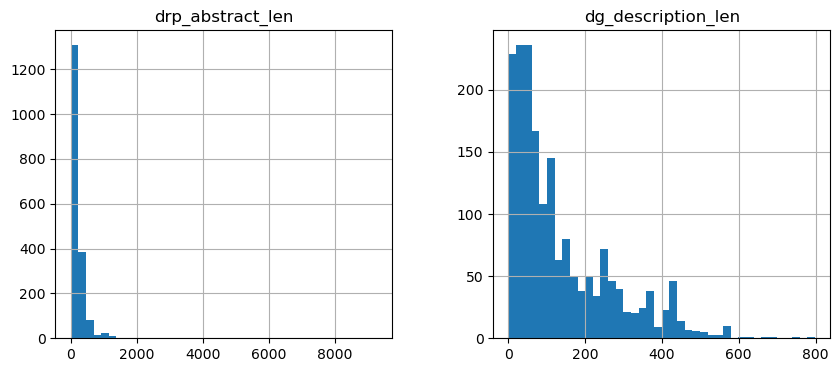

In [ ]:
match_df[["drp_abstract_len", "dg_description_len"]].hist(bins=40, figsize=(10,4))
plt.show()

match_df[["drp_metadata_count", "dg_metadata_count"]].hist(bins=15, figsize=(10,4))
plt.show()

match_df["metadata_count_diff"].hist(bins=20)
plt.show()

In [60]:
summary = pd.DataFrame({
    "metric": [
        "title_missing",
        "description_missing",
        "date_available",
        "avg_title_words",
        "avg_description_words",
        "avg_metadata_fields_present",
        "avg_subjects_keywords_count"
    ],
    "DRP": [
        match_df["drp_dc_title"].isna().mean(),
        match_df["drp_dc_abstract"].isna().mean(),
        match_df[["drp_dc_created_parsed", "drp_dc_registered_parsed", "drp_dc_updated_parsed", "drp_dc_published_parsed"]].notna().any(axis=1).mean(),
        match_df["drp_title_len"].mean(),
        match_df["drp_abstract_len"].mean(),
        match_df["drp_metadata_count"].mean(),
        match_df["drp_subjects_n"].mean()
    ],
    "data.gov": [
        match_df["dg_title"].isna().mean(),
        match_df["dg_description"].isna().mean(),
        match_df["dg_last_harvested_date_parsed"].notna().mean(),
        match_df["dg_title_len_words"].mean(),
        match_df["dg_description_len"].mean(),
        match_df["dg_metadata_count"].mean(),
        match_df[["dg_keywords_n", "dg_themes_n"]].mean(axis=1).mean()
    ]
})

print(summary)

                        metric         DRP    data.gov
0                title_missing    0.000000    0.000000
1          description_missing    0.000000    0.000000
2               date_available    1.000000    1.000000
3              avg_title_words    9.447729    8.939245
4        avg_description_words  195.481117  137.133005
5  avg_metadata_fields_present   10.690203    7.995074
6  avg_subjects_keywords_count    1.021346    4.457581


In [62]:
date_cols = [
    "drp_dc_created",
    "drp_dc_registered",
    "drp_dc_updated",
    "drp_dc_published",
    "drp_dc_date_issued",
    "dg_last_harvested_date"
]

for c in date_cols:
    match_df[c] = pd.to_datetime(match_df[c], errors="coerce")

In [64]:
print(match_df[date_cols].notna().mean().sort_values(ascending=False))

drp_dc_created            1.000000
drp_dc_registered         1.000000
drp_dc_updated            1.000000
drp_dc_published          1.000000
dg_last_harvested_date    1.000000
drp_dc_date_issued        0.979201
dtype: float64


In [66]:
match_df["dg_dcat"].dropna().iloc[0]

{'@type': 'dcat:Dataset',
 'accessLevel': 'public',
 'contactPoint': {'@type': 'vcard:Contact',
  'fn': 'OR_FRAMEWORK',
  'hasEmail': 'mailto:gis.info@das.oregon.gov'},
 'description': 'Abstract: This file contains Hydrologic Unit (HU) polygon boundaries for the United States, Puerto Rico, and the U.S. Virgin Islands. The data is a seamless National representation of HU boundaries from 2 to 14 digits compiled from U.S. Geological Survey (USGS) National Hydrography Dataset (NHD) and U.S. Department of Agriculture (USDA) National Resources Conservation Service (NRCS) Watershed Boundary Dataset (WBD) sources. Purpose: This data is intended primarily for geographic display and analysis of regional and national data, and can also be used for illustration purposes at intermediate or small scales (1:250,000 to 1:2,000,000). See https://apps.nationalmap.gov/help/ for assistance with The National Map viewer, download client, services, or metadata.',
 'distribution': [{'@type': 'dcat:Distributio

In [67]:
import pandas as pd

df = match_df.copy()

def extract_dcat_field(x, key):
    if isinstance(x, dict):
        return x.get(key)
    return None

df["dg_issued"] = df["dg_dcat"].apply(lambda x: extract_dcat_field(x, "issued"))
df["dg_modified"] = df["dg_dcat"].apply(lambda x: extract_dcat_field(x, "modified"))

df["dg_issued"] = pd.to_datetime(df["dg_issued"], errors="coerce")
df["dg_modified"] = pd.to_datetime(df["dg_modified"], errors="coerce")

In [68]:
df["drp_dc_published"] = pd.to_datetime(df["drp_dc_published"], errors="coerce")
df["drp_dc_updated"] = pd.to_datetime(df["drp_dc_updated"], errors="coerce")

In [69]:
print(
    pd.DataFrame({
        "drp_published": df["drp_dc_published"].notna().mean(),
        "drp_updated": df["drp_dc_updated"].notna().mean(),
        "dg_issued": df["dg_issued"].notna().mean(),
        "dg_modified": df["dg_modified"].notna().mean()
    }, index=["availability"])
)

              drp_published  drp_updated  dg_issued  dg_modified
availability            1.0          1.0   0.684182     0.719759


In [79]:
df["published_lag_days"] = (
    df["drp_dc_published"] - df["dg_issued"]
).dt.days

In [80]:
print(
    df[["published_lag_days"]]
    .describe()
)

       published_lag_days
count                 0.0
mean                  NaN
std                   NaN
min                   NaN
25%                   NaN
50%                   NaN
75%                   NaN
max                   NaN


In [ ]:
df["published_lag_years"] = df["published_lag_days"] / 365.25

print(
    df[["published_lag_śśears"]]
    .describe()
)

       published_lag_years
count          1250.000000
mean            -51.007665
std               3.639184
min             -56.131417
25%             -53.541410
50%             -51.649555
75%             -49.114305
max             -26.997947


In [77]:
df["drp_dc_published"].describe()

count                             1827
mean     1970-01-01 00:00:00.000002025
min      1970-01-01 00:00:00.000001980
25%      1970-01-01 00:00:00.000002025
50%      1970-01-01 00:00:00.000002025
75%      1970-01-01 00:00:00.000002026
max      1970-01-01 00:00:00.000002026
Name: drp_dc_published, dtype: object

In [78]:
import pandas as pd

def fix_epoch_year(x):
    if pd.isna(x):
        return pd.NaT
    
    try:
        ts = pd.to_datetime(x)
        year = ts.microsecond
        if 1900 <= year <= 2100:
            return pd.Timestamp(f"{year}-01-01")
    except:
        pass
    
    return pd.NaT

df["drp_dc_published"] = df["drp_dc_published"].apply(fix_epoch_year)

In [75]:
print(
    "DRP published later than data.gov issued:",
    (df["published_lag_days"] > 0).mean()
)


DRP published later than data.gov issued: 0.0


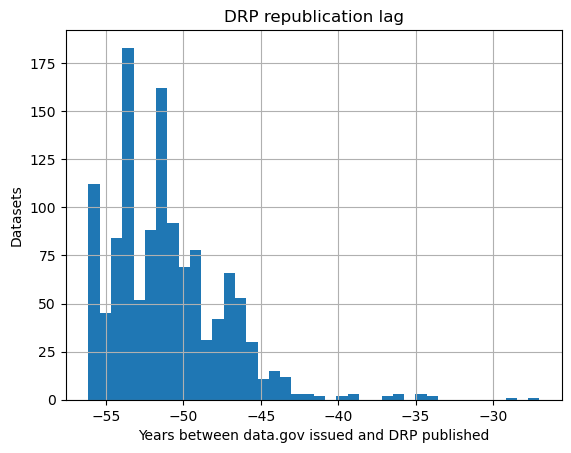

In [76]:
import matplotlib.pyplot as plt

df["published_lag_years"].dropna().hist(bins=40)
plt.xlabel("Years between data.gov issued and DRP published")
plt.ylabel("Datasets")
plt.title("DRP republication lag")
plt.show()

In [18]:
match_df.loc[
    match_df["match_score"].between(0.85, 0.9),
    ["drp_title_x","dg_title","match_score"]
].sample(20)

,drp_title_x,dg_title,match_score
1293,Percentage of Service-Connected Disabled Who U...,Percentage of Service-Connected Disabled Who D...,0.887755
1145,NNDSS - Table II. Cryptosporidiosis to Dengue ...,NNDSS - Table II. Cryptosporidiosis to Dengue,0.893617
901,National Survey of Substance Abuse Treatment S...,National Survey of Substance Abuse Treatment S...,0.890756
1017,NNDSS - Table 1H. Cholera to Coccidioidomycosi...,NNDSS - Table 1H. Cholera to Coccidioidomycosis,0.897959
1199,NNDSS - Table II. Tetanus to Vibriosis (nf22-9...,NNDSS - Table II. Tetanus to Vibriosis,0.875000
568,Hazard MItigation Plan Statuses,Hazard Mitigation Plan Statuses (OpenFEMA),0.873239
1175,NNDSS - Table II. Lyme disease to Meningococca...,NNDSS - Table II. Lyme disease to Meningococcal,0.897959
1173,NNDSS - Table II. Legionellosis to Malaria (33...,NNDSS - Table II. Legionellosis to Malaria,0.886364
1597,TABLE III. Deaths in 122 U.S. cities (7esm-uptm),TABLE III. Deaths in 122 U.S. cities,0.871795
1143,NNDSS - Table II. Cryptosporidiosis to Dengue ...,NNDSS - Table II. Cryptosporidiosis to Dengue,0.893617


In [19]:
match_df_good = match_df[match_df["match_score"] >= 0.85].copy()

In [20]:
len(match_df_good)

1143

In [21]:
len(match_df_good) / len(match_df)

0.625615763546798

In [22]:
match_df_good["drp_index"].nunique()

1143

In [23]:
match_df_good["drp_index"].nunique() / len(df_drp)

0.4501772351319417

In [24]:
sorted(match_df_good.columns)

['dg__score',
 'dg__sort',
 'dg_dcat',
 'dg_description',
 'dg_first_token',
 'dg_harvest_record',
 'dg_harvest_record_raw',
 'dg_harvest_record_transformed',
 'dg_has_spatial',
 'dg_identifier',
 'dg_index',
 'dg_keyword',
 'dg_last_harvested_date',
 'dg_organization',
 'dg_popularity',
 'dg_publisher',
 'dg_slug',
 'dg_spatial_shape',
 'dg_theme',
 'dg_title',
 'dg_title_len',
 'dg_title_norm',
 'drp_Unnamed: 0',
 'drp_agency',
 'drp_category',
 'drp_data_source',
 'drp_dc_abstract',
 'drp_dc_alternateIdentifiers',
 'drp_dc_citationCount',
 'drp_dc_contributors_all',
 'drp_dc_created',
 'drp_dc_creators_all',
 'drp_dc_creators_names',
 'drp_dc_creators_types',
 'drp_dc_date_collected',
 'drp_dc_date_issued',
 'drp_dc_dates_all',
 'drp_dc_descriptions_all',
 'drp_dc_downloadCount',
 'drp_dc_error',
 'drp_dc_fundingReferences',
 'drp_dc_geoLocations_all',
 'drp_dc_geo_places',
 'drp_dc_identifiers',
 'drp_dc_isActive',
 'drp_dc_isVersionOf',
 'drp_dc_language',
 'drp_dc_metadataVersion

Creating negative dataset

In [25]:
dg_positive_ids = set(match_df_good["dg_index"])

In [26]:
df_dg_pool = df_dg.loc[~df_dg.index.isin(dg_positive_ids)].copy()

In [27]:
df_dg_pool = df_dg_pool[
    df_dg_pool["title"].notna()
]

df_dg_pool = df_dg_pool[
    df_dg_pool["description"].notna()
]

In [28]:
df_dg_pool["desc_word_count"] = (
    df_dg_pool["description"]
    .astype(str)
    .str.split()
    .str.len()
)

df_dg_pool = df_dg_pool[df_dg_pool["desc_word_count"] >= 40]

In [29]:
import re

with open("../general/data/banned_words_PEN.txt") as f:
    pen_words = [w.strip().lower() for w in f if w.strip()]

with open("../general/data/banned_words.txt") as f:
    nyt_words = [w.strip().lower() for w in f if w.strip()]

banned_words = list(set(pen_words + nyt_words))

pattern = re.compile(r"\b(" + "|".join(map(re.escape, banned_words)) + r")\b", re.IGNORECASE)

In [30]:
def contains_flagged(text):
    if not isinstance(text, str):
        return False
    return bool(pattern.search(text))

df_dg_pool["has_flagged"] = (
    df_dg_pool["title"].apply(contains_flagged) |
    df_dg_pool["description"].apply(contains_flagged)
)

df_dg_pool = df_dg_pool[~df_dg_pool["has_flagged"]]

In [31]:
n_pos = len(match_df_good)

df_controls = df_dg_pool.sample(
    n=n_pos,
    random_state=42
)

In [32]:
df_pos = pd.DataFrame({
    "title": match_df_good["dg_title"],
    "description": match_df_good["dg_description"],
    "target": 1
})

In [33]:
df_neg = pd.DataFrame({
    "title": df_controls["title"],
    "description": df_controls["description"],
    "target": 0
})

In [34]:
df_model = pd.concat([df_pos, df_neg], ignore_index=True)

df_model = df_model.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [35]:
print(df_model["target"].value_counts())

print(
    df_model.groupby("target")["description"]
    .apply(lambda x: x.str.split().str.len().mean())
)

target
0    1143
1    1143
Name: count, dtype: int64
target
0    170.815398
1    155.384952
Name: description, dtype: float64


In [41]:
df_model = add_flagged_column(df_model, abstract_col='description', title_col='title' )

In [42]:
df_model.groupby("target")["n_banned_terms_total"].mean()

target
0    0.001750
1    2.271216
Name: n_banned_terms_total, dtype: float64

In [43]:
df_model.groupby("target")["has_flagged_word_total"].mean()

target
0    0.001750
1    0.452318
Name: has_flagged_word_total, dtype: float64

In [37]:
df_model.to_csv('00_data/df_drpdatagov.csv')